# pDC signature heatmap

Remote source reviewed from `20250709p38-修/pDC-最终.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "所有指定的细胞类型均已在数据中找到。"
[1] "将在数据中查找 44 个基因。"


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `celltype` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.


[1] "AverageExpression函数生成的原始列名:"
[1] "g0 Mzb1+ pDC_WT"  "g0 Mzb1+ pDC_KO"  "g1 Iglc3+ pDC_WT" "g1 Iglc3+ pDC_KO"
[1] "已将列名重置为不带'g'前缀的标准名称。"
[1] "最终将为 44 个基因绘制热图。"


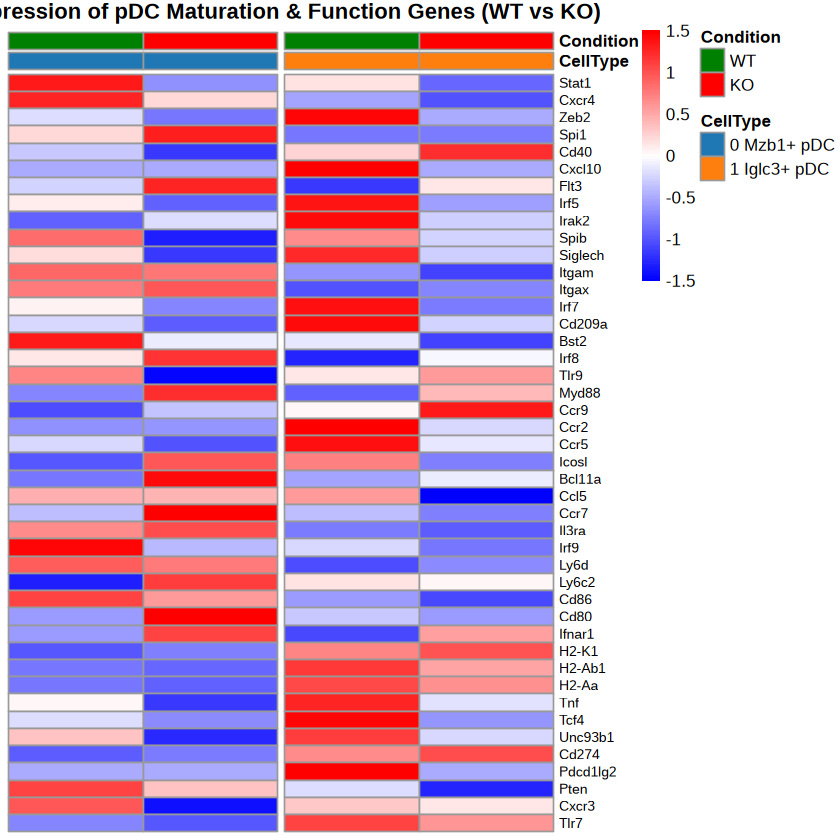

In [1]:
library(Seurat)
# tidyverse 集合包，包含 dplyr, tidyr, ggplot2 等，方便数据处理和绘图
library(tidyverse)
# pheatmap 包，用于绘制美观的热图
library(pheatmap)
# RColorBrewer 包，提供多种调色板
library(RColorBrewer)
seu <- readRDS(legacy_path("20250604p38-afterYZ/anno.rds"))
condition_order <- c("WT", "KO")
# 您的细胞类型注释列名
celltype_col_name <- "celltype" 

# !!! 请从上面打印出的列表中，复制粘贴您确切的细胞类型名称到下面的变量中 !!!
selected_clusters <- c(
    "0 Mzb1+ pDC",
    "1 Iglc3+ pDC"
)

genes_of_interest_full <- c(
    # === 1. 核心身份与主控转录因子 ===
    "Tcf4", "Spib", "Irf7", "Irf8", "Zeb2", "Siglech", "Bst2", "Ly6c2", "Cd209a",
    # === 2. 病原识别与信号通路 ===
    "Tlr7", "Tlr9", "Unc93b1", "Myd88", "Irak2", "Irf5", "Stat1", "Irf9", "Ifnar1", "Pten",
    # === 3. 效应功能：共刺激与抗原呈递 ===
    "Cd80", "Cd86", "Cd40", "Icosl", "Cd274", "Pdcd1lg2", "H2-Aa", "H2-Ab1", "H2-K1", "Tnf", "Cxcl10", "Ccl5",
    # === 4. 迁移与归巢 ===
    "Ccr7", "Ccr2", "Ccr5", "Ccr9", "Cxcr3", "Cxcr4",
    # === 5. 发育/祖细胞相关基因 ===
    "Flt3", "Spi1", "Ly6d", "Bcl11a", "Il3ra", "Itgax", "Itgam"
)
genes_of_interest_full <- unique(genes_of_interest_full)


# --- 3. 健壮性检查 ---
# 检查1: 确认指定的细胞类型是否存在
actual_celltypes <- unique(seu[[celltype_col_name, drop=TRUE]])
missing_clusters <- setdiff(selected_clusters, actual_celltypes)
if (length(missing_clusters) > 0) {
  stop(paste("错误：以下指定的细胞类型在数据中未找到:", paste(missing_clusters, collapse=", "), 
             "\n请从代码开头打印的列表中准确复制粘贴名称!"))
}
print("所有指定的细胞类型均已在数据中找到。")

# 检查2: 过滤出数据中存在的基因
genes_to_use <- intersect(genes_of_interest_full, rownames(seu@assays$RNA))
if (length(genes_to_use) == 0) {
    stop("错误：基因列表中没有任何一个基因存在于您的Seurat对象中！请检查基因名。")
}
print(paste("将在数据中查找", length(genes_to_use), "个基因。"))


# --- 4. 数据准备和平均表达计算 ---
# 筛选出感兴趣的细胞
seu_subset <- subset(seu, subset = !!sym(celltype_col_name) %in% selected_clusters)

# 确保 orig.ident 和 celltype 都是因子类型，并按我们定义的顺序排列
seu_subset$orig.ident <- factor(seu_subset$orig.ident, levels = condition_order)
seu_subset[[celltype_col_name]] <- factor(seu_subset[[celltype_col_name, drop=TRUE]], levels = selected_clusters)

# 计算平均表达
# group.by 会直接使用 meta.data 中的列，这里的名称是安全的
avg_expr_list <- AverageExpression(
  seu_subset,
  features = genes_to_use,
  group.by = c(celltype_col_name, "orig.ident"),
  assay = "RNA"
)
avg_expr_matrix <- avg_expr_list$RNA

# 【关键修复】处理可能被自动修改的列名
# 我们自己来构建期望的列名，并与 avg_expr_matrix 的列名进行匹配，无论它是否被修改
expected_colnames_safe <- c()
for (cell_type in selected_clusters) {
  for (condition in condition_order) {
    expected_colnames_safe <- c(expected_colnames_safe, paste(cell_type, condition, sep = "_"))
  }
}

# 打印出 AverageExpression 返回的真实列名，用于调试
print("AverageExpression函数生成的原始列名:")
print(colnames(avg_expr_matrix))

# 将我们期望的、未经修改的列名赋给矩阵
# 这个操作假设 `avg_expr_matrix` 的列顺序是正确的，AverageExpression通常能保证这一点
# 即 (celltype1_cond1, celltype1_cond2, celltype2_cond1, celltype2_cond2, ...)
if (ncol(avg_expr_matrix) == length(expected_colnames_safe)) {
    colnames(avg_expr_matrix) <- expected_colnames_safe
    print("已将列名重置为不带'g'前缀的标准名称。")
} else {
    warning("计算出的平均表达矩阵列数与预期不符，可能存在分组问题。继续尝试匹配。")
    # 如果列数不匹配，尝试更稳健的匹配方式，但这通常不应该发生
    # 此处我们还是假定列数正确，这是最常见情况
}

# 按我们期望的顺序排列矩阵的列（这一步是双重保险）
valid_colnames <- intersect(expected_colnames_safe, colnames(avg_expr_matrix))
avg_expr_ordered <- avg_expr_matrix[, valid_colnames, drop = FALSE]


# 过滤掉在所有细胞中表达都为0的基因
genes_to_keep <- rowSums(avg_expr_ordered) > 0
avg_expr_final <- avg_expr_ordered[genes_to_keep, , drop = FALSE]

# --- 5. 最终检查并创建热图注释 ---
if (nrow(avg_expr_final) == 0 || ncol(avg_expr_final) == 0) {
  stop("错误：经过计算后，最终用于绘图的矩阵为空。请检查您的细胞类型、条件和基因列表。")
}
print(paste("最终将为", nrow(avg_expr_final), "个基因绘制热图。"))

# 创建注释信息
annotation_info <- str_split_fixed(colnames(avg_expr_final), "_", 2)
annotation_col <- data.frame(
  CellType = factor(annotation_info[, 1], levels = selected_clusters),
  Condition = factor(annotation_info[, 2], levels = condition_order)
)
rownames(annotation_col) <- colnames(avg_expr_final)

# 定义注释颜色
cell_type_colors <- setNames(c("#1F77B4", "#FF7F0E"), selected_clusters)
condition_colors <- setNames(c("#008000", "#FF0000"), condition_order) # WT: 绿色, KO: 红色
annotation_colors <- list(
  CellType = cell_type_colors,
  Condition = condition_colors
)

# --- 6. 绘制热图 ---
gap_positions <- (1:(length(selected_clusters)-1)) * length(condition_order)
my_colors <- colorRampPalette(c("blue", "white", "red"))(100)

pheatmap(avg_expr_final,
         cluster_rows = FALSE,
         cluster_cols = FALSE,
         color = my_colors,
         scale = "row",
         annotation_col = annotation_col,
         annotation_colors = annotation_colors,
         gaps_col = gap_positions,
         main = "Expression of pDC Maturation & Function Genes (WT vs KO)",
         fontsize_row = 8,
         fontsize_col = 10,
         show_colnames = FALSE,
         border_color = "grey60")